In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [1]:
import os

BASE_PATH = "/kaggle/input/datasets/xdxd003/ff-c23/FaceForensics++_C23"

real_path = os.path.join(BASE_PATH, "original")
fake_path = os.path.join(BASE_PATH, "Deepfakes")

print("Real videos:", len(os.listdir(real_path)))
print("Fake videos:", len(os.listdir(fake_path)))

Real videos: 1000
Fake videos: 1000


In [2]:
import os
import random

BASE_PATH = "/kaggle/input/datasets/xdxd003/ff-c23/FaceForensics++_C23"

real_videos = sorted(os.listdir(os.path.join(BASE_PATH, "original")))
fake_videos = sorted(os.listdir(os.path.join(BASE_PATH, "Deepfakes")))

random.seed(42)

real_subset = random.sample(real_videos, 100)
fake_subset = random.sample(fake_videos, 100)

print("Selected Real Videos:", len(real_subset))
print("Selected Fake Videos:", len(fake_subset))

Selected Real Videos: 100
Selected Fake Videos: 100


In [3]:
import os
import cv2
from tqdm import tqdm

BASE_PATH = "/kaggle/input/datasets/xdxd003/ff-c23/FaceForensics++_C23"

OUTPUT_DIR = "/kaggle/working/frames"

os.makedirs(f"{OUTPUT_DIR}/real", exist_ok=True)
os.makedirs(f"{OUTPUT_DIR}/fake", exist_ok=True)

FRAMES_PER_VIDEO = 10

In [4]:
def extract_frames(video_path, output_folder, video_id):
    cap = cv2.VideoCapture(video_path)

    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    if total_frames <= 0:
        cap.release()
        return

    frame_indices = [
        int(i * total_frames / FRAMES_PER_VIDEO)
        for i in range(FRAMES_PER_VIDEO)
    ]

    saved = 0

    for idx in frame_indices:
        cap.set(cv2.CAP_PROP_POS_FRAMES, idx)

        success, frame = cap.read()

        if success:
            frame_name = f"{video_id}_{saved}.jpg"

            cv2.imwrite(
                os.path.join(output_folder, frame_name),
                frame
            )

            saved += 1

    cap.release()

In [5]:
for video in tqdm(real_subset):

    video_path = os.path.join(
        BASE_PATH,
        "original",
        video
    )

    video_id = os.path.splitext(video)[0]

    extract_frames(
        video_path,
        f"{OUTPUT_DIR}/real",
        video_id
    )

100%|██████████| 100/100 [03:29<00:00,  2.10s/it]


In [6]:
for video in tqdm(fake_subset):

    video_path = os.path.join(
        BASE_PATH,
        "Deepfakes",
        video
    )

    video_id = os.path.splitext(video)[0]

    extract_frames(
        video_path,
        f"{OUTPUT_DIR}/fake",
        video_id
    )

100%|██████████| 100/100 [03:29<00:00,  2.10s/it]


In [7]:
print("Real Frames :", len(os.listdir(f"{OUTPUT_DIR}/real")))
print("Fake Frames :", len(os.listdir(f"{OUTPUT_DIR}/fake")))

Real Frames : 1000
Fake Frames : 1000


In [9]:
import cv2
import os

video_path = "/kaggle/input/datasets/xdxd003/ff-c23/FaceForensics++_C23/original/000.mp4"

cap = cv2.VideoCapture(video_path)

print("Total Frames:", int(cap.get(cv2.CAP_PROP_FRAME_COUNT)))

ret, frame = cap.read()

if ret:
    print("Frame Shape:", frame.shape)

cap.release()

Total Frames: 396
Frame Shape: (480, 640, 3)


In [10]:
import os
import cv2

video_path = "/kaggle/input/datasets/xdxd003/ff-c23/FaceForensics++_C23/original/000.mp4"

output_dir = "/kaggle/working/test_frames"
os.makedirs(output_dir, exist_ok=True)

cap = cv2.VideoCapture(video_path)

total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

frame_indices = [
    int(i * total_frames / 10)
    for i in range(10)
]

for idx, frame_no in enumerate(frame_indices):

    cap.set(cv2.CAP_PROP_POS_FRAMES, frame_no)

    ret, frame = cap.read()

    if ret:
        cv2.imwrite(
            f"{output_dir}/frame_{idx}.jpg",
            frame
        )

cap.release()

print("Done!")

Done!


In [11]:
import os

print("Saved Frames:", len(os.listdir("/kaggle/working/test_frames")))
print(os.listdir("/kaggle/working/test_frames"))

Saved Frames: 10
['frame_4.jpg', 'frame_1.jpg', 'frame_7.jpg', 'frame_0.jpg', 'frame_5.jpg', 'frame_6.jpg', 'frame_3.jpg', 'frame_2.jpg', 'frame_8.jpg', 'frame_9.jpg']


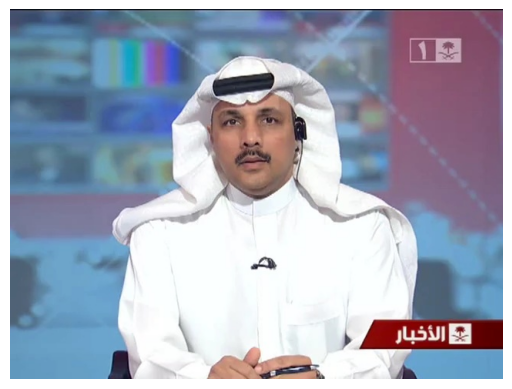

In [12]:
import matplotlib.pyplot as plt
import cv2

img = cv2.imread("/kaggle/working/test_frames/frame_0.jpg")
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(img)
plt.axis("off")
plt.show()

In [13]:
import os

OUTPUT_DIR = "/kaggle/working/deepfake_frames"

os.makedirs(f"{OUTPUT_DIR}/real", exist_ok=True)
os.makedirs(f"{OUTPUT_DIR}/fake", exist_ok=True)

In [14]:
import cv2
import os

FRAMES_PER_VIDEO = 10

def extract_frames(video_path, output_folder, video_id):

    cap = cv2.VideoCapture(video_path)

    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    if total_frames <= 0:
        cap.release()
        return

    frame_indices = [
        int(i * total_frames / FRAMES_PER_VIDEO)
        for i in range(FRAMES_PER_VIDEO)
    ]

    for idx, frame_no in enumerate(frame_indices):

        cap.set(cv2.CAP_PROP_POS_FRAMES, frame_no)

        ret, frame = cap.read()

        if ret:
            cv2.imwrite(
                os.path.join(output_folder, f"{video_id}_{idx}.jpg"),
                frame
            )

    cap.release()

In [15]:
from tqdm import tqdm
import os

real_path = "/kaggle/input/datasets/xdxd003/ff-c23/FaceForensics++_C23/original"

for video in tqdm(real_subset):

    extract_frames(
        os.path.join(real_path, video),
        f"{OUTPUT_DIR}/real",
        os.path.splitext(video)[0]
    )

100%|██████████| 100/100 [03:30<00:00,  2.11s/it]


In [16]:
from tqdm import tqdm
import os

fake_path = "/kaggle/input/datasets/xdxd003/ff-c23/FaceForensics++_C23/Deepfakes"

for video in tqdm(fake_subset):

    extract_frames(
        os.path.join(fake_path, video),
        f"{OUTPUT_DIR}/fake",
        os.path.splitext(video)[0]
    )

100%|██████████| 100/100 [03:28<00:00,  2.09s/it]


In [17]:
import os

print("Real Images:", len(os.listdir(f"{OUTPUT_DIR}/real")))
print("Fake Images:", len(os.listdir(f"{OUTPUT_DIR}/fake")))

Real Images: 1000
Fake Images: 1000


In [18]:
import os
import pandas as pd

data = []

real_dir = "/kaggle/working/deepfake_frames/real"
fake_dir = "/kaggle/working/deepfake_frames/fake"

# Real images -> label 0
for img in os.listdir(real_dir):
    data.append([
        os.path.join(real_dir, img),
        0
    ])

# Fake images -> label 1
for img in os.listdir(fake_dir):
    data.append([
        os.path.join(fake_dir, img),
        1
    ])

df = pd.DataFrame(
    data,
    columns=["image_path", "label"]
)

print(df.shape)

df.head()

(2000, 2)


,image_path,label
0,/kaggle/working/deepfake_frames/real/618_1.jpg,0
1,/kaggle/working/deepfake_frames/real/826_0.jpg,0
2,/kaggle/working/deepfake_frames/real/517_9.jpg,0
3,/kaggle/working/deepfake_frames/real/983_5.jpg,0
4,/kaggle/working/deepfake_frames/real/203_0.jpg,0


In [19]:
df["label"].value_counts()

label
0    1000
1    1000
Name: count, dtype: int64

In [20]:
df = df.sample(
    frac=1,
    random_state=42
).reset_index(drop=True)

df.head()

,image_path,label
0,/kaggle/working/deepfake_frames/fake/768_793_1...,1
1,/kaggle/working/deepfake_frames/real/250_2.jpg,0
2,/kaggle/working/deepfake_frames/fake/663_231_5...,1
3,/kaggle/working/deepfake_frames/real/046_5.jpg,0
4,/kaggle/working/deepfake_frames/fake/156_243_7...,1


In [21]:
df.to_csv(
    "/kaggle/working/deepfake_dataset.csv",
    index=False
)

print("CSV Saved!")

CSV Saved!


In [22]:
from sklearn.model_selection import train_test_split

train_df, val_df = train_test_split(
    df,
    test_size=0.2,
    stratify=df["label"],
    random_state=42
)

print("Train Size:", len(train_df))
print("Validation Size:", len(val_df))

Train Size: 1600
Validation Size: 400


In [23]:
print(train_df["label"].value_counts())

print("\nValidation\n")

print(val_df["label"].value_counts())

label
1    800
0    800
Name: count, dtype: int64

Validation

label
0    200
1    200
Name: count, dtype: int64


In [27]:
import torch
from torchvision import transforms

In [30]:
IMAGE_SIZE = 224

train_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

val_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [33]:
import cv2
import torch
from torch.utils.data import Dataset

class DeepfakeDataset(Dataset):

    def __init__(self, dataframe, transform=None):

        self.dataframe = dataframe
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):

        img_path = self.dataframe.iloc[idx]["image_path"]

        label = self.dataframe.iloc[idx]["label"]

        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        if self.transform:
            image = self.transform(image)

        return image, torch.tensor(label, dtype=torch.long)

In [34]:
train_dataset = DeepfakeDataset(
    train_df,
    transform=train_transform
)

val_dataset = DeepfakeDataset(
    val_df,
    transform=val_transform
)

In [35]:
image, label = train_dataset[0]

print("Image Shape:", image.shape)
print("Label:", label)

Image Shape: torch.Size([3, 224, 224])
Label: tensor(1)


In [36]:
from torch.utils.data import DataLoader

BATCH_SIZE = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

In [37]:
images, labels = next(iter(train_loader))

print("Images Shape:", images.shape)
print("Labels Shape:", labels.shape)

Images Shape: torch.Size([32, 3, 224, 224])
Labels Shape: torch.Size([32])


In [38]:
import torch
import torch.nn as nn
from torchvision.models import efficientnet_b0

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)

Device: cuda


In [39]:
model = efficientnet_b0(weights="DEFAULT")

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 183MB/s]


In [40]:
model.classifier[1] = nn.Linear(
    in_features=model.classifier[1].in_features,
    out_features=2
)

model = model.to(device)

In [41]:
dummy = torch.randn(1, 3, 224, 224).to(device)

with torch.no_grad():
    output = model(dummy)

print(output.shape)

torch.Size([1, 2])


In [44]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-4
)

In [46]:
from tqdm import tqdm

def train_one_epoch(model, loader, criterion, optimizer, device):

    model.train()

    running_loss = 0
    correct = 0
    total = 0

    for images, labels in tqdm(loader):

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)

        correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / len(loader)
    epoch_acc = 100 * correct / total

    return epoch_loss, epoch_acc

In [47]:
loss, acc = train_one_epoch(
    model,
    train_loader,
    criterion,
    optimizer,
    device
)

print(f"Loss: {loss:.4f}")
print(f"Accuracy: {acc:.2f}%")

100%|██████████| 50/50 [00:10<00:00,  4.65it/s]

Loss: 0.6049
Accuracy: 69.94%


In [48]:
def validate(model, loader, criterion, device):

    model.eval()

    running_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            running_loss += loss.item()

            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)

            correct += (predicted == labels).sum().item()

    val_loss = running_loss / len(loader)
    val_acc = 100 * correct / total

    return val_loss, val_acc

In [49]:
val_loss, val_acc = validate(
    model,
    val_loader,
    criterion,
    device
)

print(f"Validation Loss: {val_loss:.4f}")
print(f"Validation Accuracy: {val_acc:.2f}%")

Validation Loss: 0.4541
Validation Accuracy: 87.25%


In [50]:
NUM_EPOCHS = 5

best_val_acc = 0

for epoch in range(NUM_EPOCHS):

    train_loss, train_acc = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        device
    )

    val_loss, val_acc = validate(
        model,
        val_loader,
        criterion,
        device
    )

    print(f"\nEpoch [{epoch+1}/{NUM_EPOCHS}]")
    print(f"Train Loss: {train_loss:.4f}")
    print(f"Train Acc : {train_acc:.2f}%")
    print(f"Val Loss  : {val_loss:.4f}")
    print(f"Val Acc   : {val_acc:.2f}%")

    if val_acc > best_val_acc:

        best_val_acc = val_acc

        torch.save(
            model.state_dict(),
            "/kaggle/working/best_efficientnet.pth"
        )

        print("Model Saved!")

100%|██████████| 50/50 [00:10<00:00,  4.74it/s]



Epoch [1/5]
Train Loss: 0.3469
Train Acc : 89.62%
Val Loss  : 0.1837
Val Acc   : 94.75%
Model Saved!


100%|██████████| 50/50 [00:10<00:00,  4.67it/s]



Epoch [2/5]
Train Loss: 0.1540
Train Acc : 95.44%
Val Loss  : 0.0843
Val Acc   : 96.25%
Model Saved!


100%|██████████| 50/50 [00:10<00:00,  4.84it/s]



Epoch [3/5]
Train Loss: 0.0989
Train Acc : 96.44%
Val Loss  : 0.0596
Val Acc   : 97.25%
Model Saved!


100%|██████████| 50/50 [00:10<00:00,  4.73it/s]



Epoch [4/5]
Train Loss: 0.0726
Train Acc : 97.31%
Val Loss  : 0.0404
Val Acc   : 98.75%
Model Saved!


100%|██████████| 50/50 [00:10<00:00,  4.55it/s]



Epoch [5/5]
Train Loss: 0.0602
Train Acc : 97.88%
Val Loss  : 0.0332
Val Acc   : 99.25%
Model Saved!


In [51]:
print("Best Validation Accuracy:", best_val_acc)

Best Validation Accuracy: 99.25


In [52]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix
)

all_preds = []
all_labels = []

model.eval()

with torch.no_grad():

    for images, labels in val_loader:

        images = images.to(device)

        outputs = model(images)

        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

In [53]:
print(
    classification_report(
        all_labels,
        all_preds,
        target_names=["Real", "Fake"]
    )
)

              precision    recall  f1-score   support

        Real       0.99      0.99      0.99       200
        Fake       0.99      0.99      0.99       200

    accuracy                           0.99       400
   macro avg       0.99      0.99      0.99       400
weighted avg       0.99      0.99      0.99       400



In [54]:
cm = confusion_matrix(
    all_labels,
    all_preds
)

print(cm)

[[199   1]
 [  2 198]]


In [55]:
import timm
import torch.nn as nn

In [56]:
model_vit = timm.create_model(
    "vit_base_patch16_224",
    pretrained=True,
    num_classes=2
)

model_vit = model_vit.to(device)

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

In [58]:
dummy = torch.randn(1, 3, 224, 224).to(device)

with torch.no_grad():
    output = model_vit(dummy)

print(output.shape)

torch.Size([1, 2])


In [60]:
criterion_vit = nn.CrossEntropyLoss()

optimizer_vit = torch.optim.AdamW(
    model_vit.parameters(),
    lr=1e-4
)

In [61]:
loss, acc = train_one_epoch(
    model_vit,
    train_loader,
    criterion_vit,
    optimizer_vit,
    device
)

print(f"Loss: {loss:.4f}")
print(f"Accuracy: {acc:.2f}%")

100%|██████████| 50/50 [00:55<00:00,  1.11s/it]

Loss: 0.7962
Accuracy: 51.50%


In [62]:
NUM_EPOCHS = 5

best_val_acc_vit = 0

for epoch in range(NUM_EPOCHS):

    train_loss, train_acc = train_one_epoch(
        model_vit,
        train_loader,
        criterion_vit,
        optimizer_vit,
        device
    )

    val_loss, val_acc = validate(
        model_vit,
        val_loader,
        criterion_vit,
        device
    )

    print(f"\nEpoch [{epoch+1}/{NUM_EPOCHS}]")
    print(f"Train Loss: {train_loss:.4f}")
    print(f"Train Acc : {train_acc:.2f}%")
    print(f"Val Loss  : {val_loss:.4f}")
    print(f"Val Acc   : {val_acc:.2f}%")

    if val_acc > best_val_acc_vit:

        best_val_acc_vit = val_acc

        torch.save(
            model_vit.state_dict(),
            "/kaggle/working/best_vit.pth"
        )

        print("ViT Saved!")

100%|██████████| 50/50 [01:02<00:00,  1.25s/it]



Epoch [1/5]
Train Loss: 0.6688
Train Acc : 56.25%
Val Loss  : 0.7209
Val Acc   : 52.75%
ViT Saved!


100%|██████████| 50/50 [01:02<00:00,  1.25s/it]



Epoch [2/5]
Train Loss: 0.5830
Train Acc : 69.00%
Val Loss  : 0.8168
Val Acc   : 55.25%
ViT Saved!


100%|██████████| 50/50 [01:03<00:00,  1.26s/it]



Epoch [3/5]
Train Loss: 0.4693
Train Acc : 77.94%
Val Loss  : 0.4841
Val Acc   : 76.25%
ViT Saved!


100%|██████████| 50/50 [01:02<00:00,  1.25s/it]



Epoch [4/5]
Train Loss: 0.4702
Train Acc : 78.62%
Val Loss  : 0.3721
Val Acc   : 85.00%
ViT Saved!


100%|██████████| 50/50 [01:03<00:00,  1.26s/it]



Epoch [5/5]
Train Loss: 0.2785
Train Acc : 88.50%
Val Loss  : 0.5373
Val Acc   : 78.50%


In [63]:
from sklearn.metrics import classification_report, confusion_matrix

all_preds = []
all_labels = []

model_vit.eval()

with torch.no_grad():

    for images, labels in val_loader:

        images = images.to(device)

        outputs = model_vit(images)

        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

In [64]:
print(
    classification_report(
        all_labels,
        all_preds,
        target_names=["Real", "Fake"]
    )
)

              precision    recall  f1-score   support

        Real       0.73      0.90      0.81       200
        Fake       0.87      0.68      0.76       200

    accuracy                           0.79       400
   macro avg       0.80      0.79      0.78       400
weighted avg       0.80      0.79      0.78       400



In [65]:
cm = confusion_matrix(
    all_labels,
    all_preds
)

print(cm)

[[179  21]
 [ 65 135]]


In [66]:
!pip install grad-cam -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 74.1 MB/s eta 0:00:00:00:010:01
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 97.9 MB/s eta 0:00:00:00:010:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 

In [67]:
from pytorch_grad_cam import GradCAM

print("Grad-CAM Imported Successfully")

Grad-CAM Imported Successfully


In [68]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import torch

from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image

In [69]:
from torchvision.models import efficientnet_b0
import torch.nn as nn

model_cam = efficientnet_b0(weights=None)

model_cam.classifier[1] = nn.Linear(
    model_cam.classifier[1].in_features,
    2
)

model_cam.load_state_dict(
    torch.load(
        "/kaggle/working/best_efficientnet.pth",
        map_location=device
    )
)

model_cam.to(device)
model_cam.eval()

EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          (2): Conv2dNormActivat

In [70]:
target_layers = [model_cam.features[-1]]

In [71]:
sample_path = val_df.iloc[0]["image_path"]

print(sample_path)

/kaggle/working/deepfake_frames/real/791_9.jpg


In [73]:
import cv2
import numpy as np
import torch

img_path = "/kaggle/working/deepfake_frames/real/791_9.jpg"

img = cv2.imread(img_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

img_resized = cv2.resize(img, (224, 224))

img_float = np.float32(img_resized) / 255.0

input_tensor = val_transform(img_resized).unsqueeze(0).to(device)

In [74]:
cam = GradCAM(
    model=model_cam,
    target_layers=target_layers
)

grayscale_cam = cam(
    input_tensor=input_tensor
)[0]

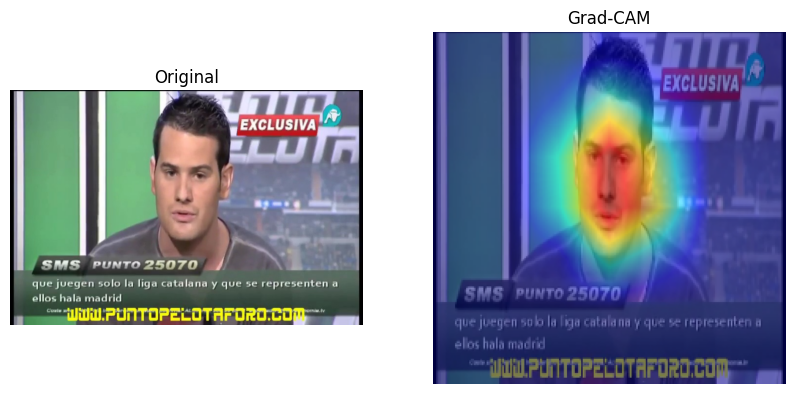

In [75]:
visualization = show_cam_on_image(
    img_float,
    grayscale_cam,
    use_rgb=True
)

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(img)
plt.title("Original")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(visualization)
plt.title("Grad-CAM")
plt.axis("off")

plt.show()

In [76]:
import cv2
import torch
import numpy as np

def predict_image(image_path):

    image = cv2.imread(image_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    transformed = val_transform(image)

    input_tensor = transformed.unsqueeze(0).to(device)

    model.eval()

    with torch.no_grad():

        outputs = model(input_tensor)

        probs = torch.softmax(outputs, dim=1)

        confidence, pred = torch.max(probs, 1)

    label = "Fake" if pred.item() == 1 else "Real"

    return label, confidence.item()

In [77]:
sample_image = "/kaggle/working/deepfake_frames/real/791_9.jpg"

label, confidence = predict_image(sample_image)

print("Prediction:", label)
print("Confidence:", round(confidence * 100, 2), "%")

Prediction: Real
Confidence: 99.9 %


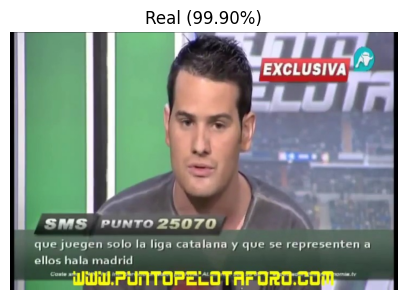

In [78]:
import matplotlib.pyplot as plt

img = cv2.imread(sample_image)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(5,5))
plt.imshow(img)
plt.title(f"{label} ({confidence*100:.2f}%)")
plt.axis("off")
plt.show()

In [79]:
import pandas as pd

results = pd.DataFrame({
    "Model": ["EfficientNet-B0", "ViT-B/16"],
    "Validation Accuracy (%)": [99.25, 85.00]
})

results

,Model,Validation Accuracy (%)
0,EfficientNet-B0,99.25
1,ViT-B/16,85.00


In [80]:
results.to_csv(
    "/kaggle/working/model_comparison.csv",
    index=False
)

print("Saved!")

Saved!


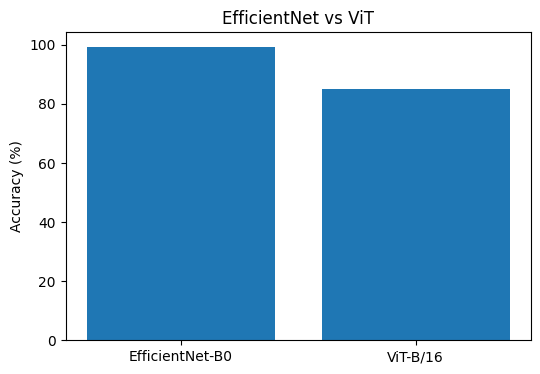

In [81]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

plt.bar(
    results["Model"],
    results["Validation Accuracy (%)"]
)

plt.ylabel("Accuracy (%)")
plt.title("EfficientNet vs ViT")

plt.show()

In [82]:
sample_images = val_df["image_path"].sample(
    5,
    random_state=42
).tolist()

sample_images

['/kaggle/working/deepfake_frames/real/203_7.jpg',
 '/kaggle/working/deepfake_frames/fake/658_627_6.jpg',
 '/kaggle/working/deepfake_frames/real/300_1.jpg',
 '/kaggle/working/deepfake_frames/real/990_2.jpg',
 '/kaggle/working/deepfake_frames/real/159_2.jpg']

In [84]:
import os

SAVE_DIR = "/kaggle/working/gradcam_examples"

os.makedirs(SAVE_DIR, exist_ok=True)

In [85]:
for idx, img_path in enumerate(sample_images):

    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    img_resized = cv2.resize(img, (224,224))
    img_float = np.float32(img_resized) / 255.0

    input_tensor = val_transform(
        img_resized
    ).unsqueeze(0).to(device)

    grayscale_cam = cam(
        input_tensor=input_tensor
    )[0]

    visualization = show_cam_on_image(
        img_float,
        grayscale_cam,
        use_rgb=True
    )

    cv2.imwrite(
        f"{SAVE_DIR}/gradcam_{idx}.jpg",
        cv2.cvtColor(
            visualization,
            cv2.COLOR_RGB2BGR
        )
    )

print("Grad-CAM Images Saved!")

Grad-CAM Images Saved!


In [86]:
import os

print(os.listdir("/kaggle/working/gradcam_examples"))

['gradcam_1.jpg', 'gradcam_0.jpg', 'gradcam_4.jpg', 'gradcam_2.jpg', 'gradcam_3.jpg']


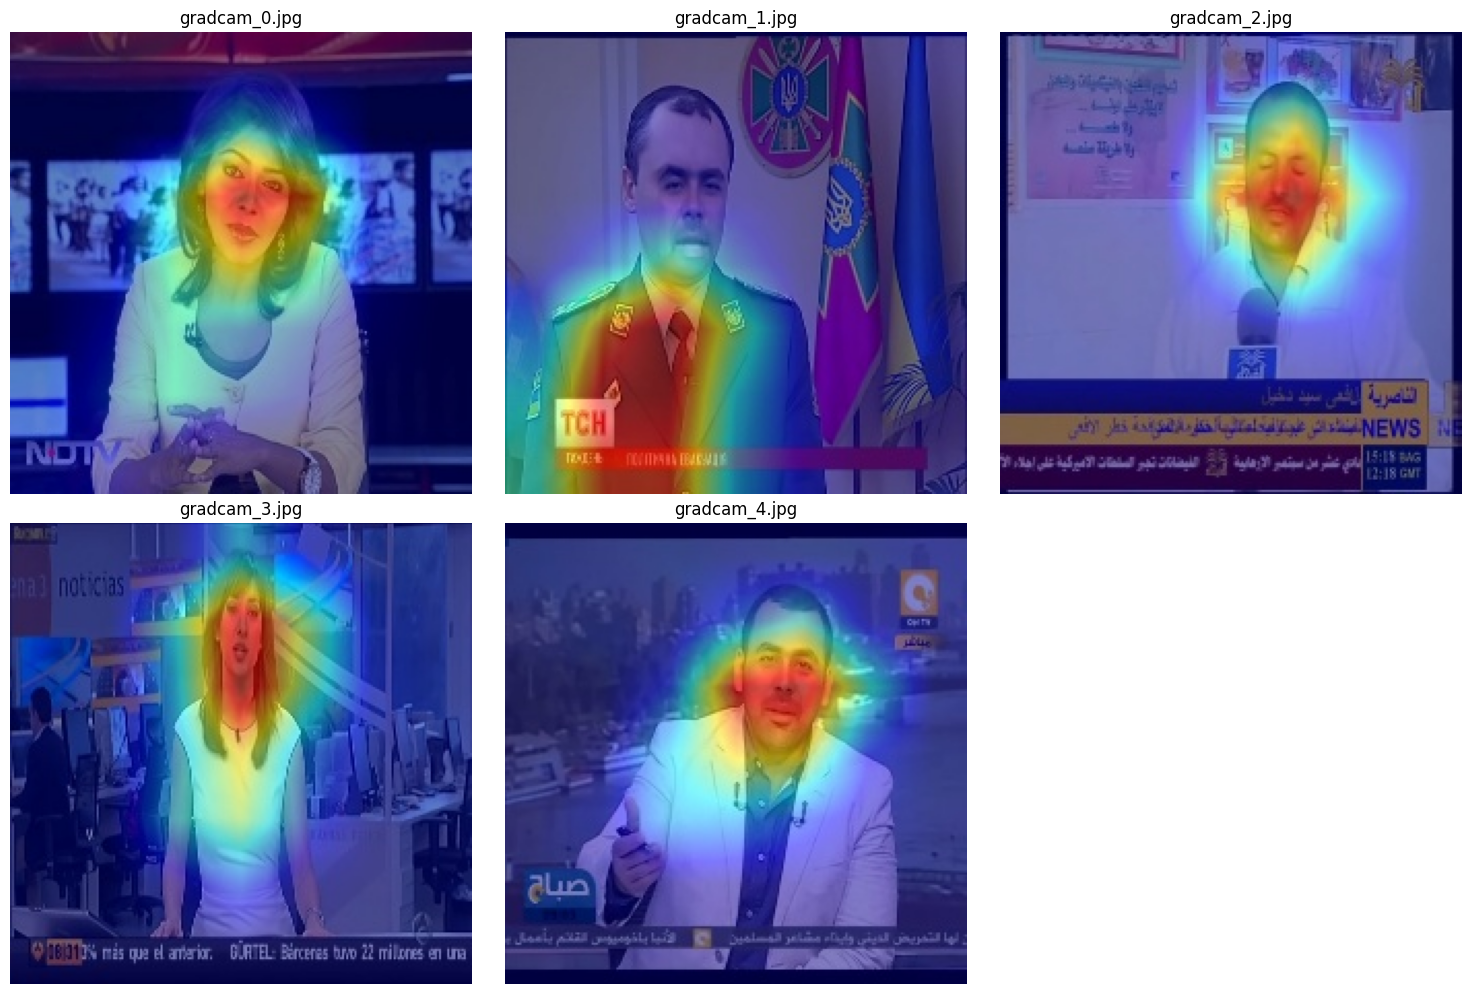

In [87]:
import os
import cv2
import matplotlib.pyplot as plt

SAVE_DIR = "/kaggle/working/gradcam_examples"

images = sorted(os.listdir(SAVE_DIR))

plt.figure(figsize=(15,10))

for i, img_name in enumerate(images):

    img_path = os.path.join(SAVE_DIR, img_name)

    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(2, 3, i + 1)
    plt.imshow(img)
    plt.title(img_name)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [88]:
real_image = "/kaggle/working/deepfake_frames/real/791_9.jpg"

label, confidence = predict_image(real_image)

print("Prediction:", label)
print("Confidence:", round(confidence * 100, 2), "%")

Prediction: Real
Confidence: 99.9 %


In [90]:
import os

fake_dir = "/kaggle/working/deepfake_frames/fake"

fake_image = os.path.join(
    fake_dir,
    os.listdir(fake_dir)[0]
)

print(fake_image)

/kaggle/working/deepfake_frames/fake/388_308_0.jpg


In [91]:
label, confidence = predict_image(fake_image)

print("Prediction:", label)
print("Confidence:", round(confidence * 100, 2), "%")

Prediction: Fake
Confidence: 99.33 %


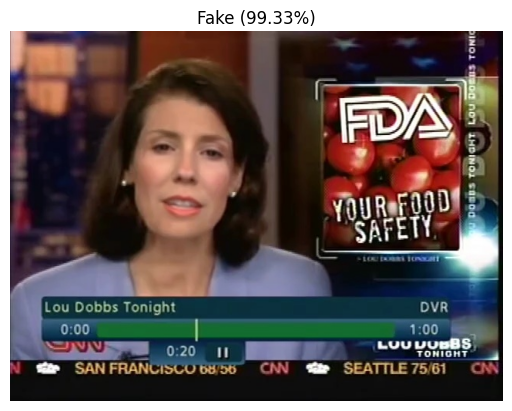

In [92]:
import cv2
import matplotlib.pyplot as plt

img = cv2.imread(fake_image)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(img)
plt.title(f"{label} ({confidence*100:.2f}%)")
plt.axis("off")
plt.show()

In [93]:
import numpy as np

def explain_prediction(pred_label, confidence):

    if pred_label == "Fake":

        if confidence > 0.95:
            return "Model detected strong manipulation cues in important facial regions."

        elif confidence > 0.80:
            return "Model found noticeable facial inconsistencies that resemble deepfake artifacts."

        else:
            return "Model found some suspicious facial patterns but with lower confidence."

    else:

        if confidence > 0.95:
            return "Facial features appear natural and consistent."

        else:
            return "No major manipulation artifacts detected."

In [94]:
label, confidence = predict_image(sample_image)

reason = explain_prediction(
    label,
    confidence
)

print("Prediction :", label)
print("Confidence :", round(confidence*100,2), "%")
print("Explanation:", reason)

Prediction : Real
Confidence : 99.9 %
Explanation: Facial features appear natural and consistent.
